
As_R1s(r) =
+373.4077 * exp(-33.7071 r)
+258.4615 * r * exp(-28.5493 r)
-1.1726 * r * exp(-15.1540 r)
+1359.0427 * r^2 * exp(-41.4602 r)
+0.4709 * r^2 * exp(-11.3318 r)
-0.0087 * r^2 * exp(-7.7302 r)
+0.0008 * r^2 * exp(-5.3683 r)
+37.3274 * r^3 * exp(-17.6911 r)
-0.0000 * r^3 * exp(-3.2155 r)
+0.0000 * r^3 * exp(-2.1464 r)
+0.0000 * r^3 * exp(-1.4740 r)

As_R2s(r) =
-116.4959 * exp(-33.7071 r)
-1095.0002 * r * exp(-28.5493 r)
+1015.5183 * r * exp(-15.1540 r)
-19.7355 * r^2 * exp(-41.4602 r)
+262.5379 * r^2 * exp(-11.3318 r)
-4.2590 * r^2 * exp(-7.7302 r)
+0.5352 * r^2 * exp(-5.3683 r)
+5460.7082 * r^3 * exp(-17.6911 r)
-0.0106 * r^3 * exp(-3.2155 r)
+0.0010 * r^3 * exp(-2.1464 r)
-0.0001 * r^3 * exp(-1.4740 r)

As_R3s(r) =
-45.3717 * exp(-33.7071 r)
-502.5207 * r * exp(-28.5493 r)
+472.1406 * r * exp(-15.1540 r)
-111.0607 * r^2 * exp(-41.4602 r)
+256.2428 * r^2 * exp(-11.3318 r)
-322.7945 * r^2 * exp(-7.7302 r)
-94.4546 * r^2 * exp(-5.3683 r)
+5637.2240 * r^3 * exp(-17.6911 r)
-0.174

/tmp/ipykernel_4480/621426076.py:146: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 1.0001010266960064
Norm 2s = 0.999999428457684
Norm 2p = 1.0000007353966167
Norm 3s = 0.9999995079424944
Norm 3p = 0.9999569603683256
Norm 3d = 0.9999996768176049
Norm 4s = 1.0000006946854634
Norm 4p = 0.9997298215949607
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.026355           0.097125       2.584613e-01   
1       0.05           0.026355           0.097115       2.582647e-01   
2       0.10           0.026354           0.097087       2.576760e-01   
3       0.15           0.026353           0.097041       2.566984e-01   
4       0.20           0.026352           0.096975       2.553368e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000024           0.000003       4.060154e-07   
1997   99.85           0.000024           0.000003       4.048642e-07   
1998   99.90           0.000024           0.000003       4.037168e-07   
1999   99.95           0.000023        

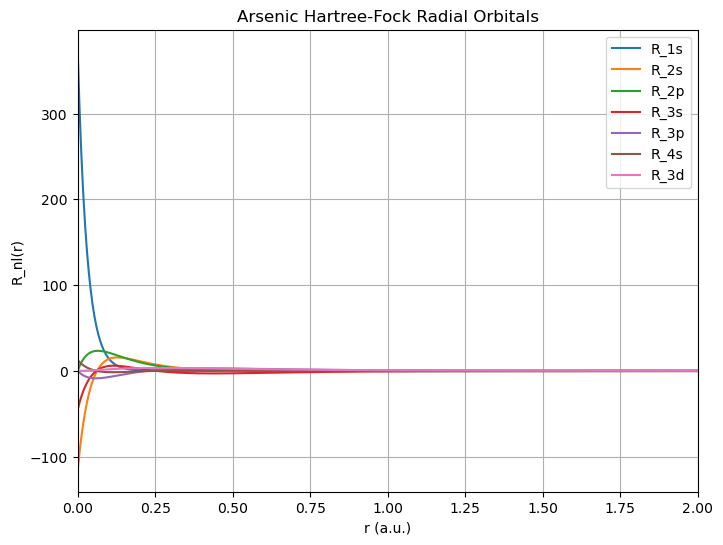

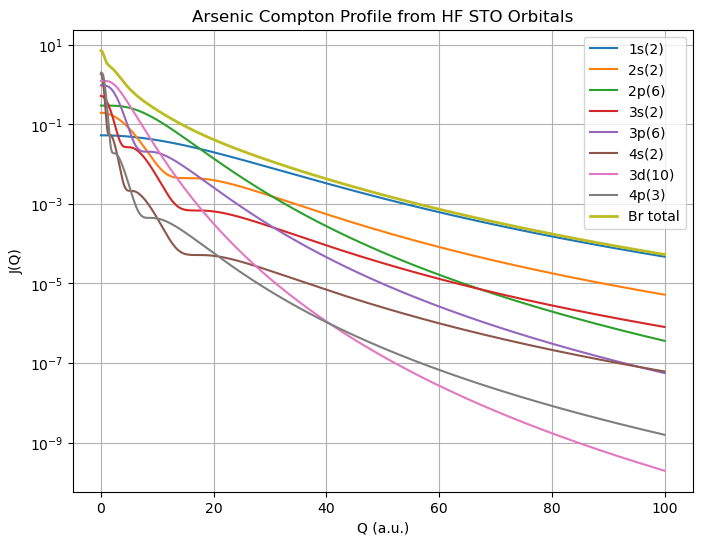

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Arsenic Hartree-Fock STO data
# As: 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p3
# =====================================================

arsenic_1s = [
    (1,33.7071, 0.954050),
    (2,28.5493, 0.051397),
    (2,15.1540,-0.001136),
    (3,41.4602,0.007024),
    (3,11.3318,0.000228),
    (3,7.7302,-0.000016),
    (3,5.3683,0.000005),
    (4,17.6911,0.000804),
    (4,3.2155,-0.000002),
    (4,2.1464,0.000002),
    (4,1.4740,0.000000),
]

arsenic_2s = [
    (1,33.7071,-0.297645),
    (2,28.5493,-0.217749),
    (2,15.1540,0.983785),
    (3,41.4602,-0.000102),
    (3,11.3318,0.127118),
    (3,7.7302,-0.007865),
    (3,5.3683,0.003541),
    (4,17.6911,0.117619),
    (4,3.2155,-0.000491),
    (4,2.1464,0.000277),
    (4,1.4740,-0.000094),
]

arsenic_3s = [
    (1,33.7071,-0.115924),
    (2,28.5493,-0.099930),
    (2,15.1540,0.457387),
    (3,41.4602,-0.000574),
    (3,11.3318,0.124070),
    (3,7.7302,-0.596101),
    (3,5.3683,-0.624965),
    (4,17.6911,0.121421),
    (4,3.2155,-0.008075),
    (4,2.1464,0.001685),
    (4,1.4740,-0.000549),
]

arsenic_4s = [
    (1,33.7071,0.031925),
    (2,28.5493,0.028203),
    (2,15.1540,-0.129153),
    (3,41.4602,0.000125),
    (3,11.3318,-0.037218),
    (3,7.7302,0.195492),
    (3,5.3683,0.211438),
    (4,17.6911,-0.038577),
    (4,3.2155,-0.393306),
    (4,2.1464,-0.536125),
    (4,1.4740,-0.206671),
]

arsenic_2p = [
    (2,33.8306,0.069915),
    (2,12.7682,0.700126),
    (3,27.7931,0.156149),
    (3,9.3346,0.021050),
    (3,6.2386,0.000000),
    (3,4.4077,0.000760),
    (4,22.4504,0.106708),
    (4,2.7882,-0.000067),
    (4,1.7792,0.000029),
    (4,1.1706,-0.000010),
]

arsenic_3p = [
    (2,33.8306,-0.011491),
    (2,12.7682,-0.453070),
    (3,27.7931,-0.016656),
    (3,9.3346,0.219149),
    (3,6.2386,0.630930),
    (3,4.4077,0.322694),
    (4,22.4504,0.007328),
    (4,2.7882,0.004166),
    (4,1.7792,-0.000064),
    (4,1.1706,-0.000022),
]

arsenic_4p = [
    (2,33.8306,-0.001866),
    (2,12.7682,-0.108812),
    (3,27.7931,0.001656),
    (3,9.3346,0.058080),
    (3,6.2386,0.161657),
    (3,4.4077,0.068207),
    (4,22.4504,0.003906),
    (4,2.7882,-0.325259),
    (4,1.7792,-0.546313),
    (4,1.1706,-0.253975),
]

arsenic_3d = [
    (3,17.0538,0.016674),
    (3,9.4108,0.239639),
    (3,5.8490,0.435884),
    (3,3.7033,0.369917),
    (3,2.3465,0.062948),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, arsenic_1s)
R2s = R_nl(r, arsenic_2s)
R3s = R_nl(r, arsenic_3s)
R4s = R_nl(r, arsenic_4s)
R2p = R_nl(r, arsenic_2p)
R3p = R_nl(r, arsenic_3p)
R4p = R_nl(r, arsenic_4p)
R3d = R_nl(r, arsenic_3d)

print_R_formula(arsenic_1s, "As_R1s")
print_R_formula(arsenic_2s, "As_R2s")
print_R_formula(arsenic_3s, "As_R3s")
print_R_formula(arsenic_4s, "As_R4s")
print_R_formula(arsenic_2p, "As_R2p")
print_R_formula(arsenic_3p, "As_R3p")
print_R_formula(arsenic_3d, "As_R3d")
print_R_formula(arsenic_4p, "As_R4p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4p = chi_p(p, r, R4p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4p, J_4p = calculate_J(p, chi_4p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))
print("Norm 4p =", np.trapezoid(I_4p, p))

# Krypton has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(5)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 10*J_3d + 2*J_4s + 3*J_4p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_4p_one electron": J_4p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(1)": 2*J_4s,
    "J_3d(10)": 10*J_3d,
    "J_4p(3)": 3*J_4p,
    "J_total_As": J_total
    })
print(table)
table.to_csv("Arsenic__STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Arsenic Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 10*J_3d, label="3d(10)")
plt.plot(Q, 3*J_4p, label="4p(3)")
plt.plot(Q, J_total, label="Br total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Arsenic Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()